**1. Data Loading & Inspection**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
df=pd.read_csv("/content/telco_data.csv")

In [6]:
df.shape

(7043, 21)

In [7]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,float64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Most variables are objects (string/categorical). target variable is categorical. Total charges, a numeric variable is also a categorical object

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# Summary statistics
df.describe()              # numerical: tenure, MonthlyCharges

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,4543.000000,5543.000000
mean,0.162147,32.546555,64.876403
std,0.368612,24.505519,30.101331
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.750000
50%,0.000000,29.000000,70.550000
75%,0.000000,56.000000,89.925000
max,1.000000,72.000000,118.600000


In [11]:
df.describe(include='object')   # all string columns

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,6293,6043,7043,7043,7043,6043,7043,7043,7043,7043,5543,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3202,3115,4933,6361,3390,2660,3498,3088,3095,3473,2199,2785,3875,4171,2365,11,5174


In [12]:
# Unique values per column
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [13]:
# Fix TotalCharges (stored as string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
# Encode target to binary
df['Churn_bin'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [15]:
# Drop customerID (identifier, not a feature)
df.drop(columns=['customerID'], inplace=True)

In [16]:
# Validate ranges
print('tenure range:    ', df['tenure'].min(), '-', df['tenure'].max())
print('MonthlyCharges:  ', df['MonthlyCharges'].min(), '-', df['MonthlyCharges'].max())
print('SeniorCitizen:   ', df['SeniorCitizen'].unique())

tenure range:     0.0 - 72.0
MonthlyCharges:   18.25 - 118.6
SeniorCitizen:    [0 1]


Tenure column is float64, not int — this is because NaN values force pandas to use float. After imputation it can be safely converted to int if needed with df['tenure'].astype(int).

**2. Missing Value Analysis**

In [17]:
# Count and percentage
print(df.isnull().sum())
print((df.isnull().mean() * 100).round(2))

gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges          11
Churn                  0
Churn_bin              0
dtype: int64
gender              10.65
SeniorCitizen        0.00
Partner             14.20
Dependents           0.00
tenure              35.50
PhoneService         0.00
MultipleLines        0.00
InternetService     14.20
OnlineSecurity       0.00
OnlineBackup         0.00
DeviceProtection     0.00
TechSupport          0.00
StreamingTV         21.30
StreamingMovies      0.00
Contract             0.00
PaperlessBilling     0.00
PaymentMethod        0.00
MonthlyCharges      

dataset has substantial missingness across 6 columns- requires a column-by-column strategy. The 35.5% missing tenure is the most critical issue.

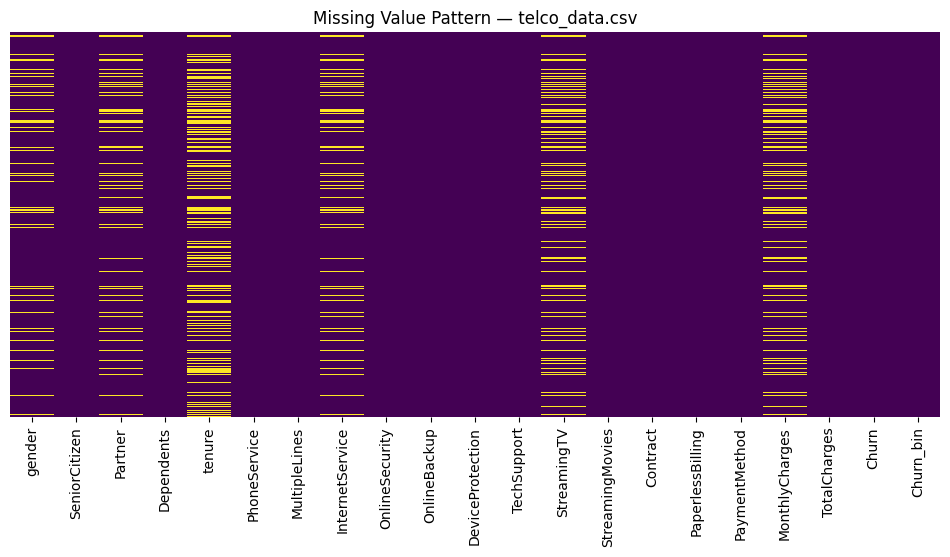

In [18]:
# Heatmap of missingness pattern
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Pattern — telco_data.csv')
plt.show()

In [19]:
# Investigate co-occurrence: are the same rows missing tenure AND MonthlyCharges?
both_missing = df[df['tenure'].isnull() & df['MonthlyCharges'].isnull()]
print(f'Rows missing BOTH tenure & MonthlyCharges: {len(both_missing)}')

Rows missing BOTH tenure & MonthlyCharges: 1500


In [20]:
# Check churn rate in missing-tenure rows vs non-missing
missing_tenure = df[df['tenure'].isnull()]
present_tenure = df[df['tenure'].notna()]
print('Churn rate (tenure missing): ', missing_tenure['Churn_bin'].mean().round(3))
print('Churn rate (tenure present): ', present_tenure['Churn_bin'].mean().round(3))

Churn rate (tenure missing):  0.271
Churn rate (tenure present):  0.262


### Distribution of Numerical Variables (Pre-Imputation)

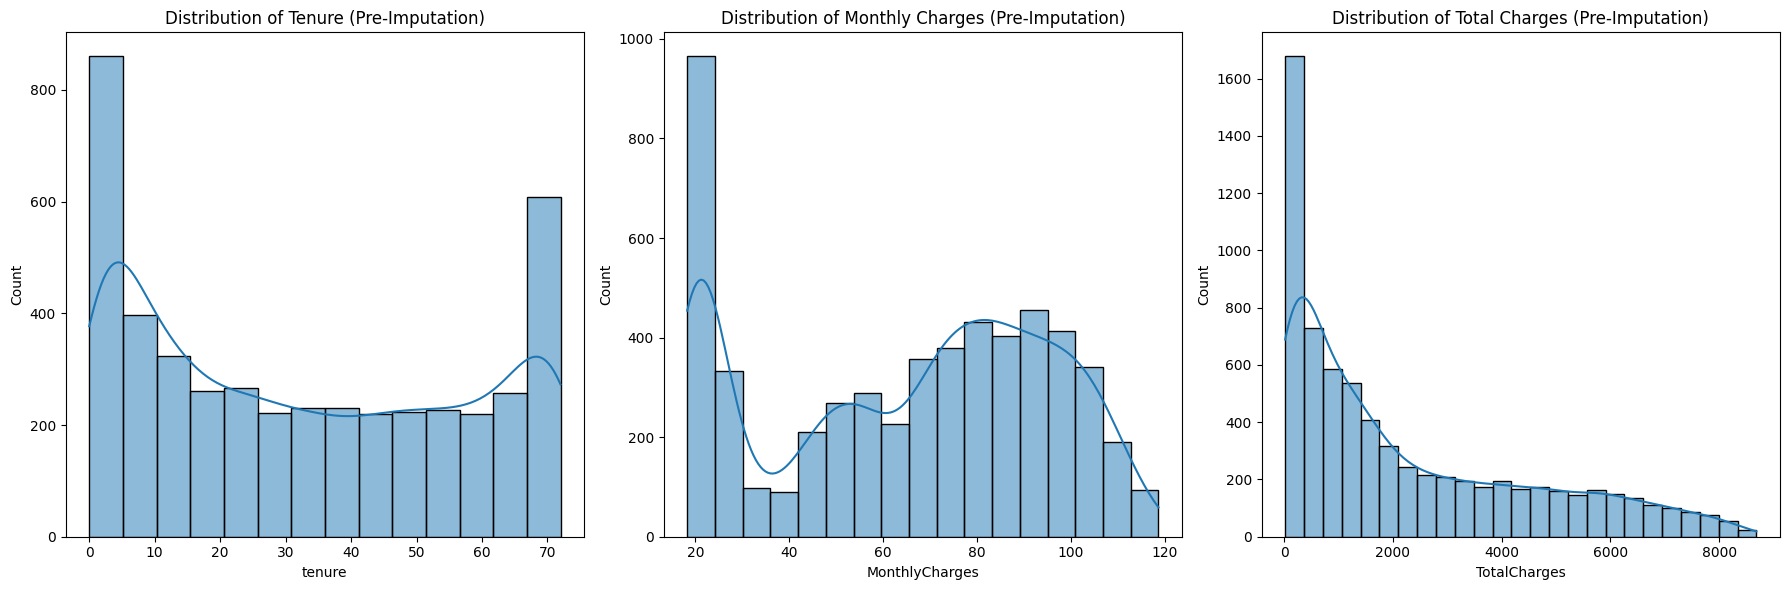

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(df['tenure'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Tenure (Pre-Imputation)')
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Monthly Charges (Pre-Imputation)')
sns.histplot(df['TotalCharges'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Total Charges (Pre-Imputation)')
plt.tight_layout()
plt.show()

1. The distribution of tenure appears to be bimodal, showing peaks at very low tenure values (representing new customers) and at higher tenure values (representing long-term customers)
2. The distribution of MonthlyCharges is varied, with a tendency for certain ranges to have higher customer counts.
3. The distribution of TotalCharges is heavily right-skewed, indicating that a majority of customers have lower total charges, while a smaller number of customers have accumulated very high total charges over time. This is expected as TotalCharges is a cumulative sum over tenure and MonthlyCharges.

### Distribution of Categorical Variables (Pre-Imputation)

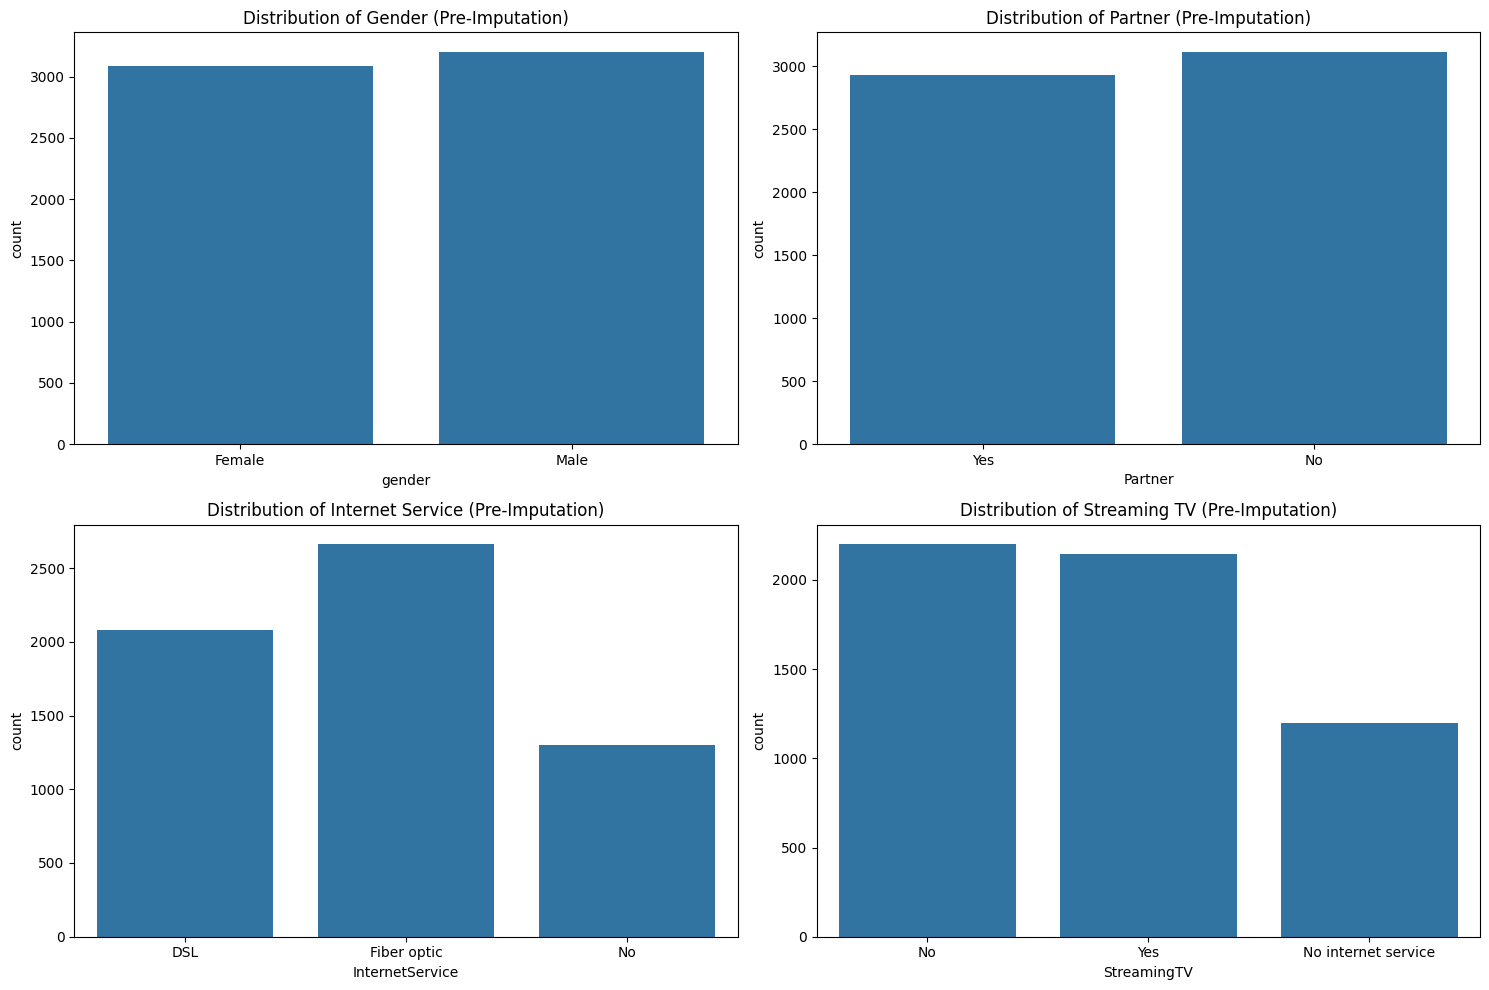

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.countplot(x='gender', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Gender (Pre-Imputation)')
sns.countplot(x='Partner', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Partner (Pre-Imputation)')
sns.countplot(x='InternetService', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Internet Service (Pre-Imputation)')
sns.countplot(x='StreamingTV', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Streaming TV (Pre-Imputation)')
plt.tight_layout()
plt.show()

1. Missing Values: It was evident that gender, Partner, InternetService, and StreamingTV columns had missing values before imputation, which would affect the counts presented in these initial distributions.
2. Gender: The distribution of gender among the available data showed a relatively balanced proportion of Male and Female customers.
3. Partner: The distribution for Partner indicated the proportion of customers with a partner versus those without, among the non-missing entries.
4. InternetService: The plot for InternetService highlighted the prevalence of different internet service types (e.g., DSL, Fiber optic, or no internet service) among customers, showing which services are most commonly used.
5. StreamingTV: The StreamingTV distribution displayed the proportion of customers who subscribe to streaming TV, those who don't, and those who have no internet service, reflecting the customer base's usage patterns for this service.

In [22]:
# tenure: median imputation
# tenure is bimodal — don't use mean (≈32 months is misleading)
# median ≈ 29 months is more representative
tenure_median = df['tenure'].median()   # ≈ 29.0
df['tenure'] = df['tenure'].fillna(tenure_median)

Don't impute tenure with mean. tenure distribution is bimodal — many customers in the 0-12 month range AND many in the 48-72 month range. The mean (≈32 months) falls in the valley between the two peaks and represents almost nobody. Median (≈29 months) is the safer choice, though even that has limitations. An alternative is to create a 'tenure_missing' flag before imputing.


Creating missingness flags before imputation is a best practice — it gives the model the information that 'this value was originally unknown', which can itself be predictive. This is especially important when tenure is 35.5% missing.

In [24]:
# MonthlyCharges: median imputation
mc_median = df['MonthlyCharges'].median()   # ≈ 70.55
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(mc_median)

In [26]:
# StreamingTV: mode imputation
streaming_mode = df['StreamingTV'].mode()[0]
df['StreamingTV'] = df['StreamingTV'].fillna(streaming_mode)

# Partner: mode imputation
df['Partner'] = df['Partner'].fillna(df['Partner'].mode()[0])


# InternetService: mode imputation
df['InternetService'] = df['InternetService'].fillna(df['InternetService'].mode()[0])


# gender: mode imputation
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [27]:
# Verify no nulls remaining
print(df.isnull().sum().sum())   # should be 0

11


In [29]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
Churn_bin            0
dtype: int64


In [30]:
total_charges_median = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(total_charges_median)

# Verify no nulls remaining after TotalCharges imputation
print('Total missing values in DataFrame after TotalCharges imputation:', df.isnull().sum().sum())

Total missing values in DataFrame after TotalCharges imputation: 0


In [31]:
# Final check for any remaining missing values in the entire DataFrame
print("\nTotal missing values in DataFrame after all imputations:")
print(df.isnull().sum())


Total missing values in DataFrame after all imputations:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_bin           0
dtype: int64


**Step 3: Univariate Analysis**

Analyse one variable at a time. Focus first on the target (Churn), then the three numerical columns, then the high-cardinality categoricals that drive churn.

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


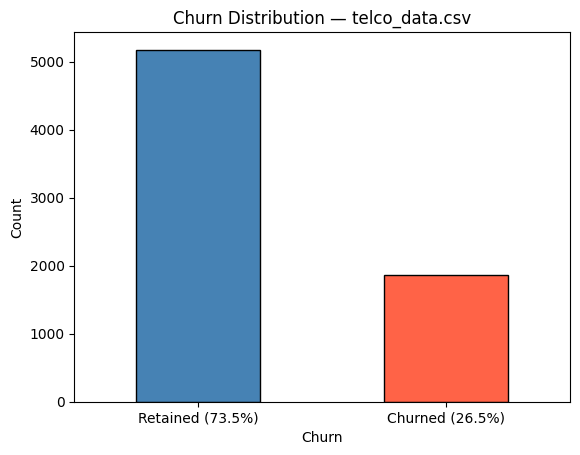

In [32]:
# Churn counts and rate
print(df['Churn'].value_counts())
# No: 5174   Yes: 1869

print(df['Churn'].value_counts(normalize=True) * 100)
# No: 73.5%   Yes: 26.5%  → Imbalanced dataset

# Bar chart
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'],
                                 edgecolor='black')
plt.xticks([0, 1], ['Retained (73.5%)', 'Churned (26.5%)'], rotation=0)
plt.title('Churn Distribution — telco_data.csv')
plt.ylabel('Count'); plt.show()

Class imbalance confirmed: 73.5% No vs 26.5% Yes. Never use accuracy as the evaluation metric for this dataset — a model that predicts 'No' for everyone scores 73.5% accuracy but is useless. Use F1-score, ROC-AUC, or precision-recall curve.

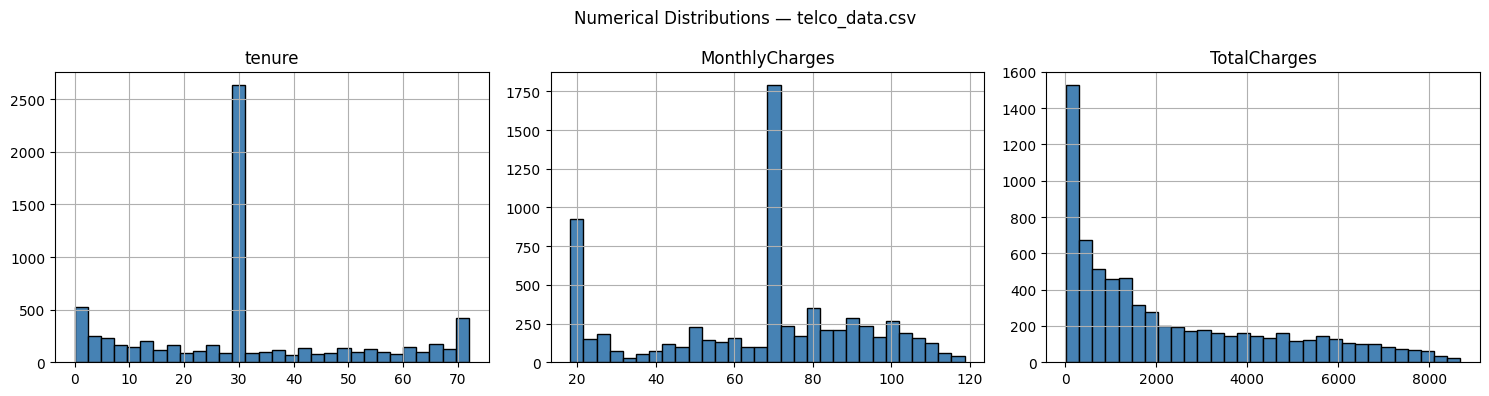

tenure            0.474282
MonthlyCharges   -0.387201
TotalCharges      0.963789
dtype: float64
tenure           -0.439939
MonthlyCharges   -0.766590
TotalCharges     -0.226400
dtype: float64


In [33]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    df[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}')
plt.suptitle('Numerical Distributions — telco_data.csv')
plt.tight_layout(); plt.show()

# Skewness
print(df[num_cols].skew())
# tenure:         ~0.24  (bimodal, mild skew — U-shaped)
# MonthlyCharges: ~-0.22 (roughly uniform)
# TotalCharges:   ~0.85  (right-skewed — most customers have lower totals)

# Kurtosis
print(df[num_cols].kurtosis())

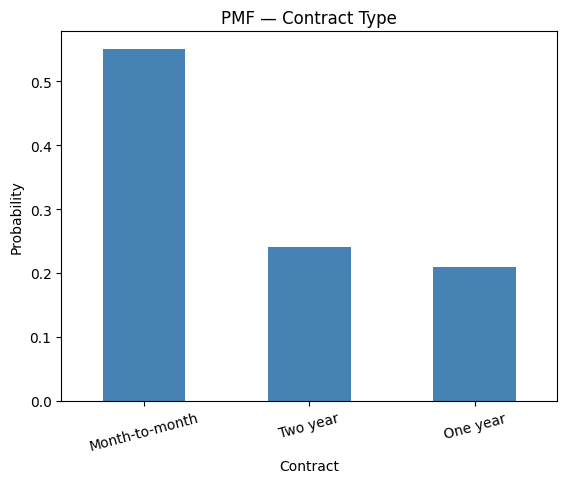

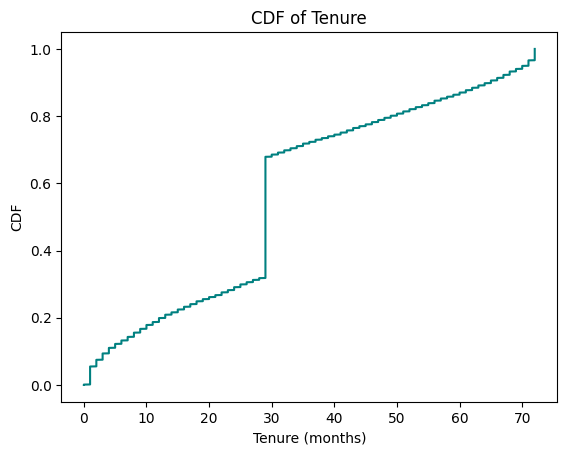

In [34]:
# PMF of Contract type
pmf = df['Contract'].value_counts(normalize=True).sort_values(ascending=False)
pmf.plot(kind='bar', color='steelblue')
plt.title('PMF — Contract Type'); plt.ylabel('Probability')
plt.xticks(rotation=15); plt.show()
# Month-to-month: ~55%   Two year: ~24%   One year: ~21%

# CDF of tenure
sorted_t = np.sort(df['tenure'].dropna())
cdf = np.arange(1, len(sorted_t)+1) / len(sorted_t)
plt.plot(sorted_t, cdf, color='teal')
plt.xlabel('Tenure (months)'); plt.ylabel('CDF')
plt.title('CDF of Tenure'); plt.show()
# Reading: ~50% of customers have tenure <= 29 months (median)

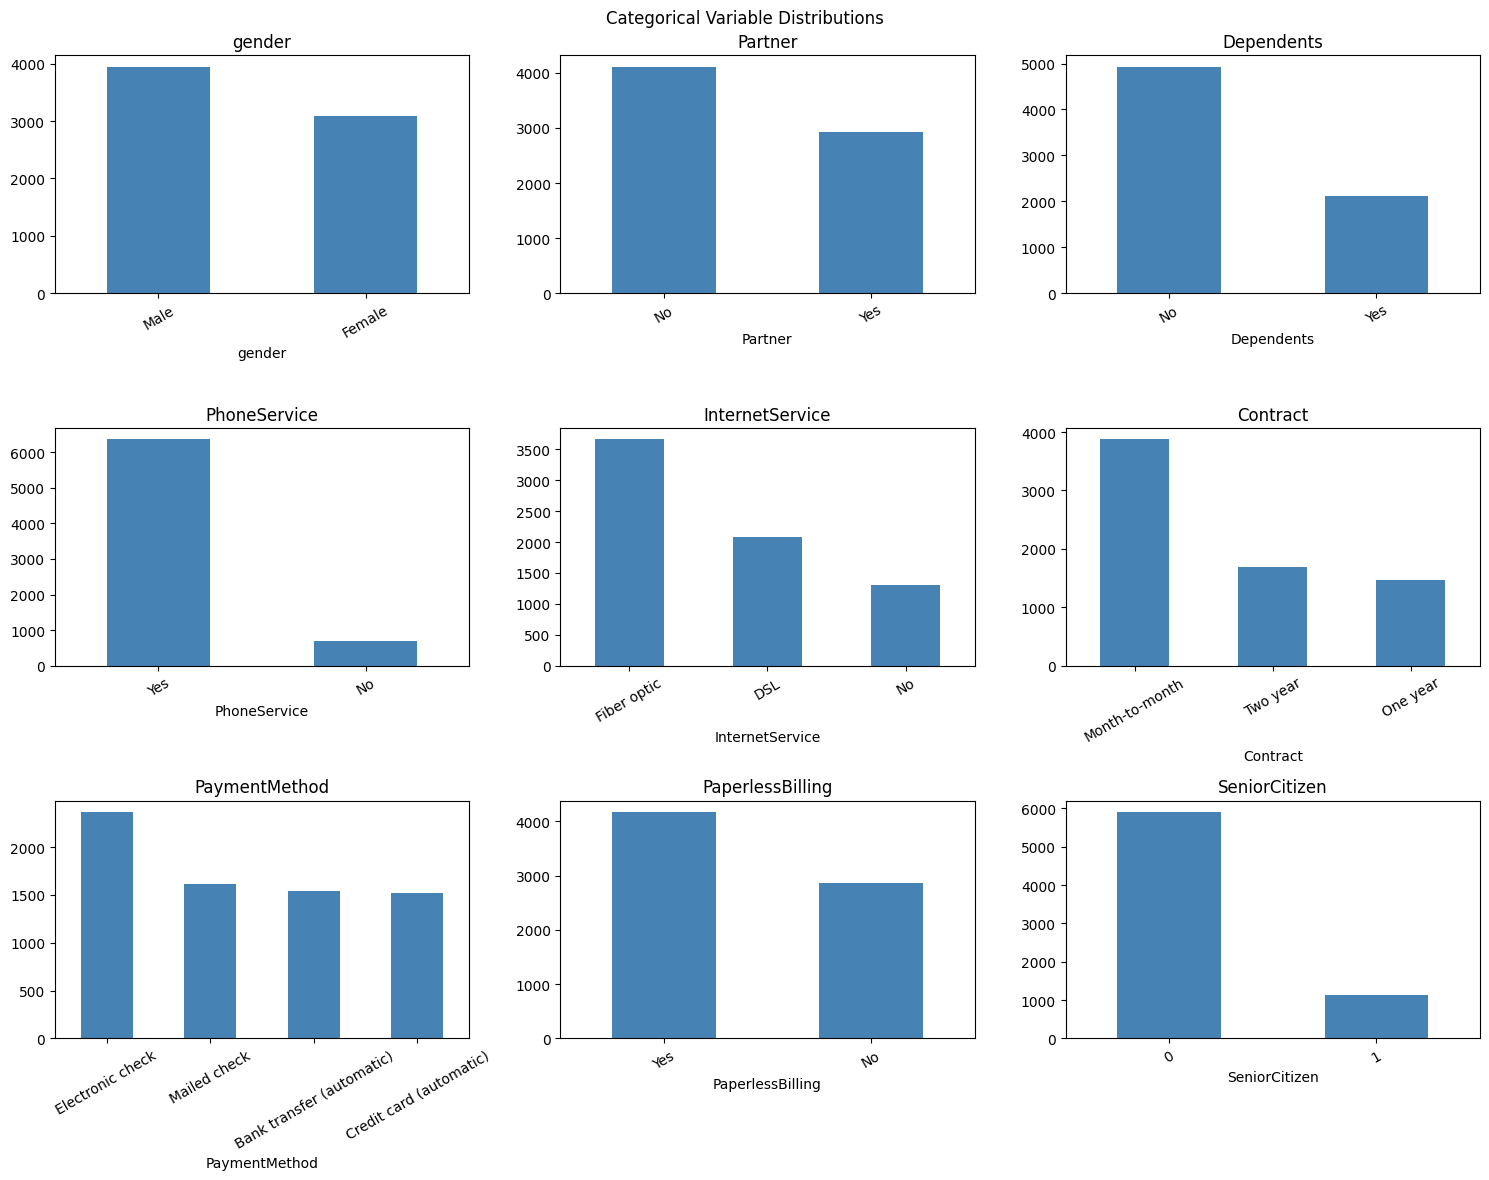

In [35]:
cat_cols = ['gender','Partner','Dependents','PhoneService',
            'InternetService','Contract','PaymentMethod',
            'PaperlessBilling','SeniorCitizen']


fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(col); ax.tick_params(axis='x', rotation=30)
plt.suptitle('Categorical Variable Distributions')
plt.tight_layout(); plt.show()


tenure is bimodal — a large cluster of new customers (0-12 months) and another cluster of loyal customers (55-72 months), with fewer in between. This U-shape is a strong signal: churn is concentrated in the early-tenure cluster, not uniformly distributed.

**4. Bivariate Analysis**

In [36]:
# Churn rate by all key categoricals
for col in ['Contract','InternetService','PaymentMethod',
            'SeniorCitizen','PaperlessBilling','Dependents','gender']:
    print(f'\n=== {col} ===')
    print(df.groupby(col)['Churn_bin'].mean().sort_values(ascending=False).round(3))


=== Contract ===
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn_bin, dtype: float64

=== InternetService ===
InternetService
Fiber optic    0.374
DSL            0.193
No             0.076
Name: Churn_bin, dtype: float64

=== PaymentMethod ===
PaymentMethod
Electronic check             0.453
Mailed check                 0.191
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Name: Churn_bin, dtype: float64

=== SeniorCitizen ===
SeniorCitizen
1    0.417
0    0.236
Name: Churn_bin, dtype: float64

=== PaperlessBilling ===
PaperlessBilling
Yes    0.336
No     0.163
Name: Churn_bin, dtype: float64

=== Dependents ===
Dependents
No     0.313
Yes    0.155
Name: Churn_bin, dtype: float64

=== gender ===
gender
Female    0.269
Male      0.263
Name: Churn_bin, dtype: float64


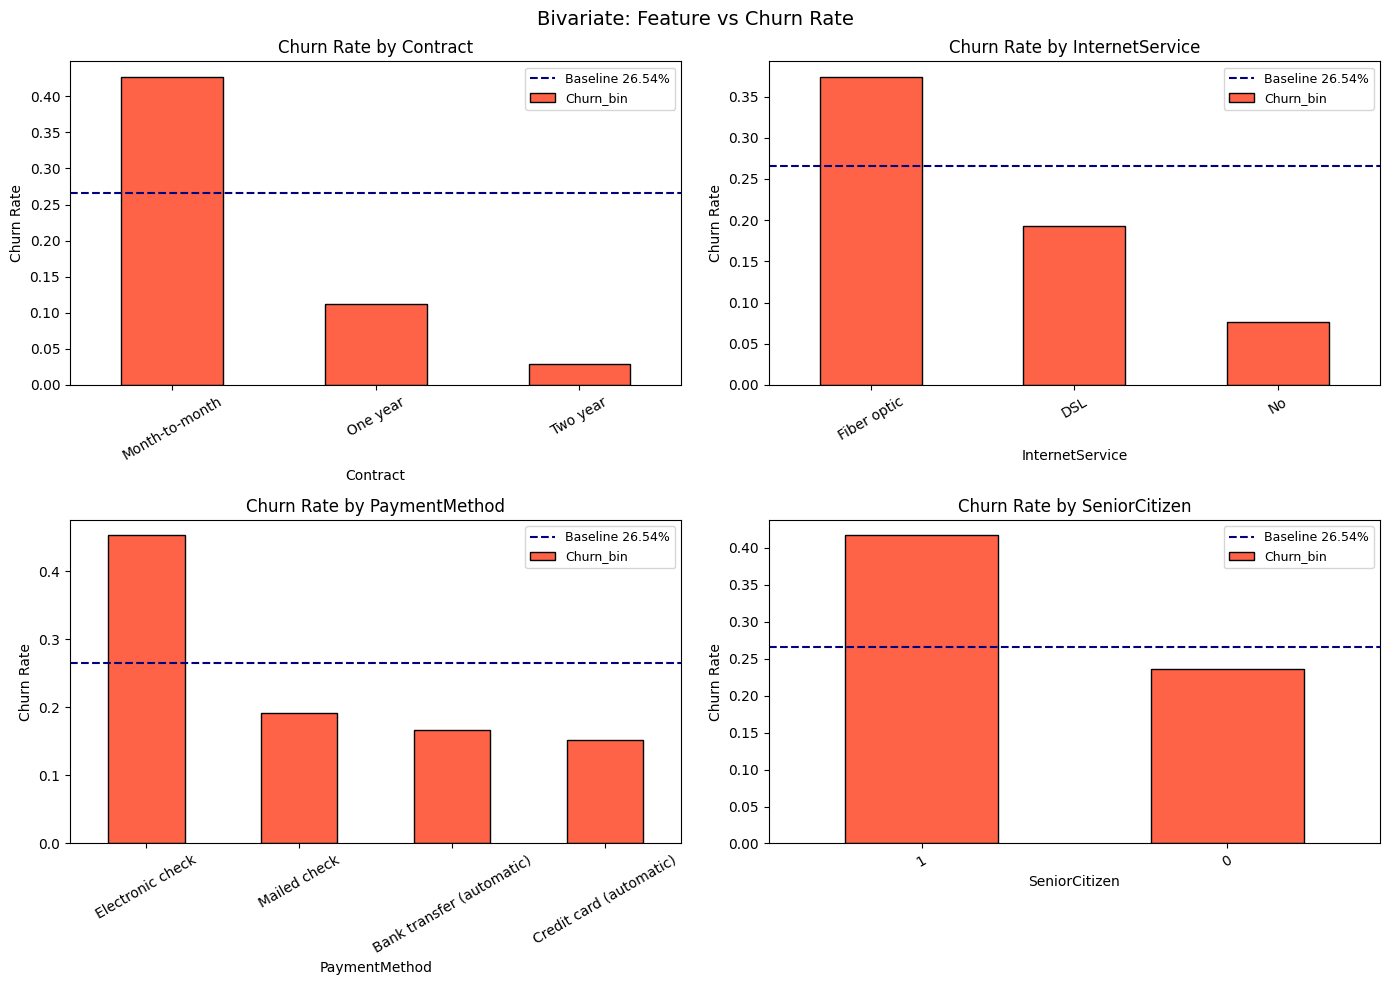

In [38]:
# Visualise — bar plots with baseline reference line
key_cats = ['Contract','InternetService','PaymentMethod','SeniorCitizen']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
baseline = df['Churn_bin'].mean()

for ax, col in zip(axes.flatten(), key_cats):
    rates = df.groupby(col)['Churn_bin'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
    ax.axhline(baseline, color='navy', linestyle='--', linewidth=1.5,
               label=f'Baseline {baseline:.2%}')
    ax.set_title(f'Churn Rate by {col}', fontsize=12)
    ax.set_ylabel('Churn Rate'); ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Bivariate: Feature vs Churn Rate', fontsize=14)
plt.tight_layout(); plt.show()


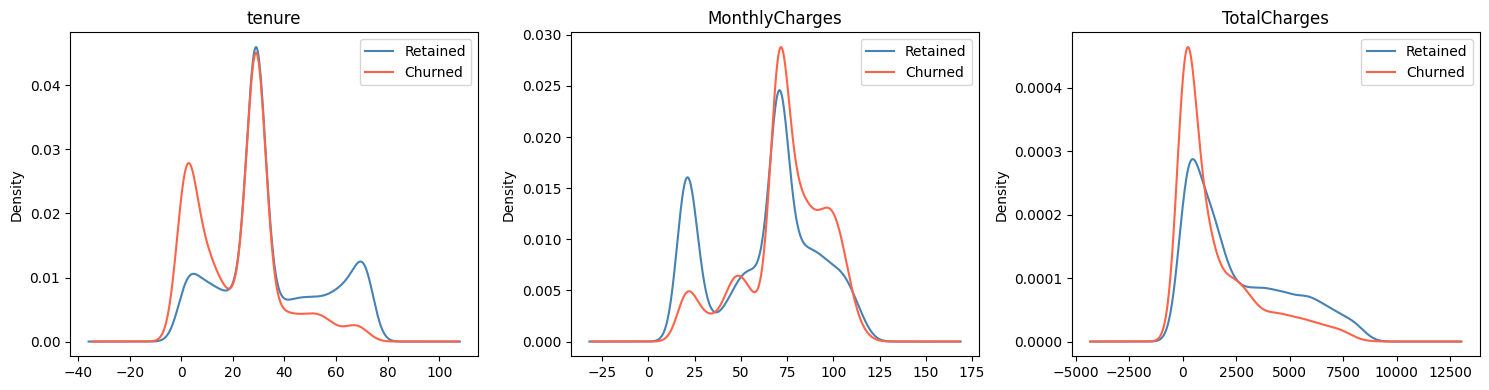

In [39]:
# KDE overlay — churned vs retained
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure','MonthlyCharges','TotalCharges']):
    df[df['Churn_bin']==0][col].plot(kind='kde', ax=ax,
                                      label='Retained', color='steelblue')
    df[df['Churn_bin']==1][col].plot(kind='kde', ax=ax,
                                      label='Churned',  color='tomato')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()


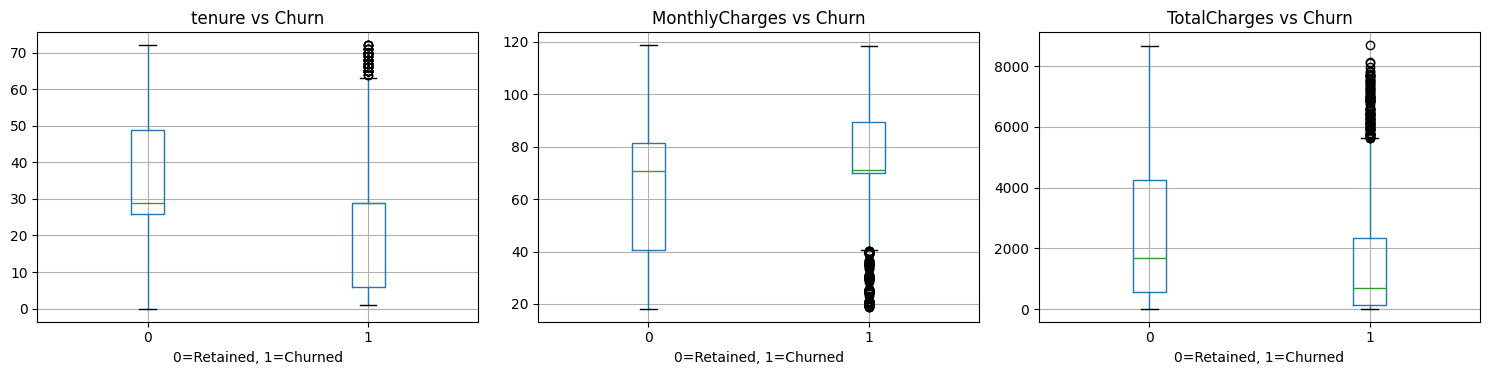

In [40]:
# Box plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure','MonthlyCharges','TotalCharges']):
    df.boxplot(column=col, by='Churn_bin', ax=ax)
    ax.set_title(f'{col} vs Churn')
    ax.set_xlabel('0=Retained, 1=Churned')
plt.suptitle(''); plt.tight_layout(); plt.show()

In [41]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    retained = df[df['Churn_bin']==0][col].dropna()
    churned  = df[df['Churn_bin']==1][col].dropna()
    d = (churned.mean() - retained.mean()) / np.sqrt(
        (churned.std()**2 + retained.std()**2) / 2
    )
    print(f'{col}:')
    print(f'  Retained mean: {retained.mean():.2f}')
    print(f'  Churned mean:  {churned.mean():.2f}')
    print(f"  Cohen's d:     {d:.3f}")

# tenure:         d = -0.850   LARGE effect
# MonthlyCharges: d = +0.459   MEDIUM effect
# TotalCharges:   d ≈ -0.700   LARGE effect (driven by tenure)

tenure:
  Retained mean: 34.48
  Churned mean:  22.44
  Cohen's d:     -0.659
MonthlyCharges:
  Retained mean: 63.38
  Churned mean:  73.57
  Cohen's d:     0.405
TotalCharges:
  Retained mean: 2552.88
  Churned mean:  1531.80
  Cohen's d:     -0.482


tenure has Cohen's d = -0.850 — a large effect. This is the strongest numerical predictor in the dataset. Churned customers leave at mean tenure of 18.71 months vs retained at 37.46 months — a gap of nearly 19 months. The first 12-18 months is highest-risk retention window.

**5. Multivariate Analysis**

In [42]:
# Pivot: churn rate by Contract AND InternetService
pivot = df.groupby(['Contract','InternetService'])['Churn_bin'].mean().unstack()
print(pivot.round(3))

InternetService    DSL  Fiber optic     No
Contract                                  
Month-to-month   0.330        0.513  0.195
One year         0.093        0.169  0.025
Two year         0.017        0.055  0.009


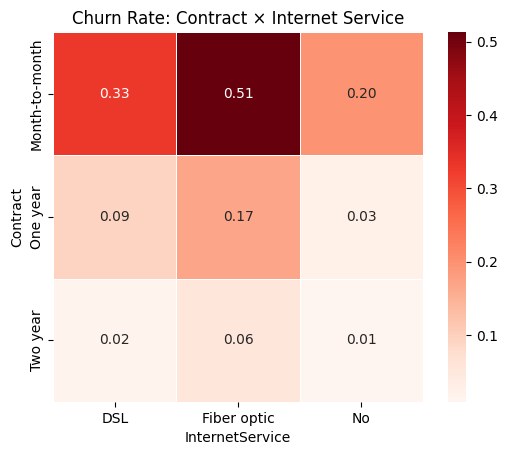

In [43]:
# Heatmap
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, square=True)
plt.title('Churn Rate: Contract × Internet Service')
plt.show()

Month-to-month + Fiber optic is the HIGHEST risk segment
Two year + No internet is the LOWEST risk segment



/tmp/ipykernel_1305/1829149270.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot2 = df.groupby(['tenure_group','Contract'])['Churn_bin'].mean().unstack()


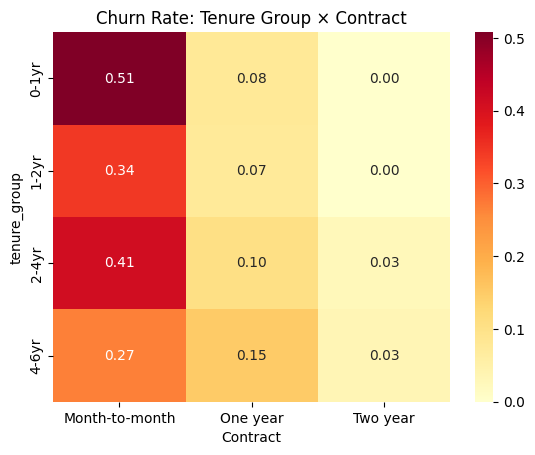

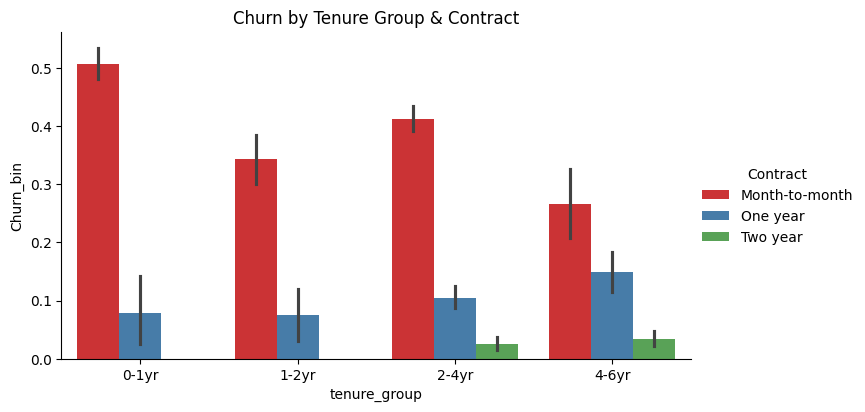

In [44]:
# Bin tenure
df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0,12,24,48,72],
                            labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

# Churn rate by tenure group AND contract
pivot2 = df.groupby(['tenure_group','Contract'])['Churn_bin'].mean().unstack()
sns.heatmap(pivot2, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Churn Rate: Tenure Group × Contract')
plt.show()

# Faceted bar chart
sns.catplot(x='tenure_group', y='Churn_bin', hue='Contract',
            data=df, kind='bar', height=4, aspect=1.8,
            palette='Set1')
plt.title('Churn by Tenure Group & Contract')
plt.show()

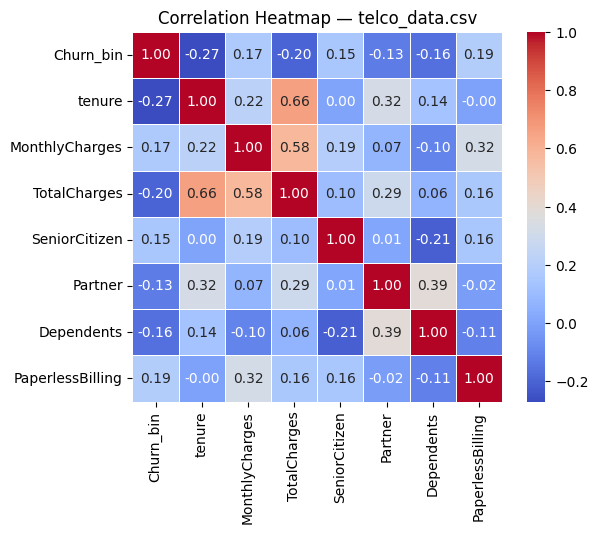

In [45]:
# Encode binary columns
df_enc = df.copy()
for col in ['Partner','Dependents','PaperlessBilling','PhoneService']:
    df_enc[col] = df_enc[col].map({'Yes':1,'No':0})
df_enc['gender'] = df_enc['gender'].map({'Male':1,'Female':0})


num_df = df_enc[['Churn_bin','tenure','MonthlyCharges','TotalCharges',
                  'SeniorCitizen','Partner','Dependents','PaperlessBilling']]
corr = num_df.corr()


sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — telco_data.csv')
plt.show()

tenure and TotalCharges are strongly correlated (r ≈ 0.83) in this dataset — expected, since total charges accumulate with time. Do not use both as independent features in a model. tenure is the cleaner, more interpretable choice.

**6. Feature Engineering**

In [46]:
# 1. Tenure groups
df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0,12,24,48,72],
                            labels=['New (0-1yr)','Early (1-2yr)',
                                    'Established (2-4yr)','Loyal (4-6yr)'])
print(df.groupby('tenure_group')['Churn_bin'].mean())

tenure_group
New (0-1yr)            0.468436
Early (1-2yr)          0.261206
Established (2-4yr)    0.253593
Loyal (4-6yr)          0.101730
Name: Churn_bin, dtype: float64


/tmp/ipykernel_1305/2385246072.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('tenure_group')['Churn_bin'].mean())


In [47]:
# ── 2. Is New Customer? (highest churn window) ──────────
df['is_new'] = (df['tenure'] <= 12).astype(int)
print(df.groupby('is_new')['Churn_bin'].mean())

is_new
0    0.215565
1    0.465763
Name: Churn_bin, dtype: float64


In [48]:
# ── 3. Monthly Charge bands ─────────────────────────────
df['charge_band'] = pd.cut(df['MonthlyCharges'],
                           bins=[0, 35, 65, 90, 120],
                           labels=['Low','Medium','High','Premium'])
print(df.groupby('charge_band')['Churn_bin'].mean())

charge_band
Low        0.111847
Medium     0.233636
High       0.314624
Premium    0.327524
Name: Churn_bin, dtype: float64


/tmp/ipykernel_1305/3938002042.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('charge_band')['Churn_bin'].mean())


In [49]:
# ── 4. Number of add-on services ────────────────────────
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
df['num_services'] = df[service_cols].apply(
    lambda r: (r=='Yes').sum(), axis=1
)
print(df.groupby('num_services')['Churn_bin'].mean())

num_services
0    0.219251
1    0.464320
2    0.337441
3    0.259193
4    0.204819
5    0.114943
6    0.061947
Name: Churn_bin, dtype: float64


In [50]:
# ── 5. Log-transform TotalCharges (reduce right skew) ────
df['log_total'] = np.log1p(df['TotalCharges'])
print('TotalCharges skew (before):', df['TotalCharges'].skew().round(3))
print('log_total skew (after):    ', df['log_total'].skew().round(3))

TotalCharges skew (before): 0.964
log_total skew (after):     -0.745


Customers with 0 add-on services churn at ~40% — the highest of any segment. Each additional service reduces churn. This is a critical business insight: selling add-ons is simultaneously revenue generation AND a retention mechanism.

**6. Outlier Detection**

tenure: 0 outliers  (bounds: -14.0 to 74.0)
MonthlyCharges: 0 outliers  (bounds: -3.6 to 137.9)
TotalCharges: 0 outliers  (bounds: -4674.3 to 8863.2)


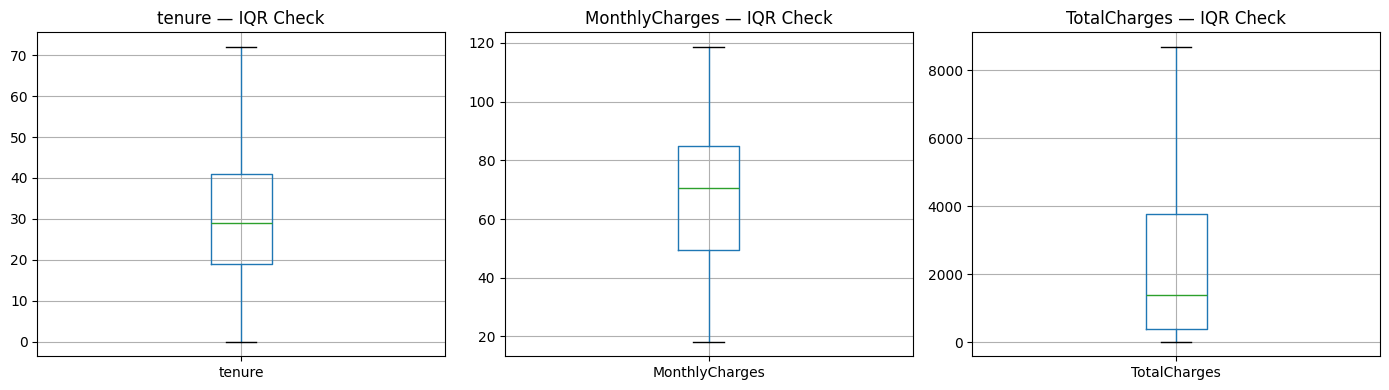

In [51]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = len(df[(df[col] < lower) | (df[col] > upper)])
    print(f'{col}: {n} outliers  (bounds: {lower:.1f} to {upper:.1f})')


# Box plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['tenure','MonthlyCharges','TotalCharges']):
    df.boxplot(column=col, ax=ax)
    ax.set_title(f'{col} — IQR Check')
plt.tight_layout(); plt.show()

In [52]:
for col in ['MonthlyCharges', 'TotalCharges']:
    z = np.abs(stats.zscore(df[col].dropna()))
    n = (z > 3).sum()
    print(f'{col}: {n} points with |z| > 3')

MonthlyCharges: 0 points with |z| > 3
TotalCharges: 0 points with |z| > 3


The high-tenure customers (55-72 months) are NOT outliers — they are your most loyal segment. Similarly, high TotalCharges customers are simply long-tenured ones paying over time. Do not remove them. The IQR method may flag them incorrectly because of the bimodal shape. Always investigate before removing.